[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>
Dataset columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Sample Data:
                                                 Product  \
29904  Credit reporting, credit repair services, or o...   
30629  Credit reporting, credit repair services, or o...   
30735  Credit reporting, credit repair services, or o...   
30795  Credit reporting, credit repair services, or o...   
30807  Credit reporting, credit repair services, or o...   

                            Consumer complaint narrative  
29904  The Summer of XX/XX/2018 I was denied a mortga...  
30629  There are many mistakes appear in my rep

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


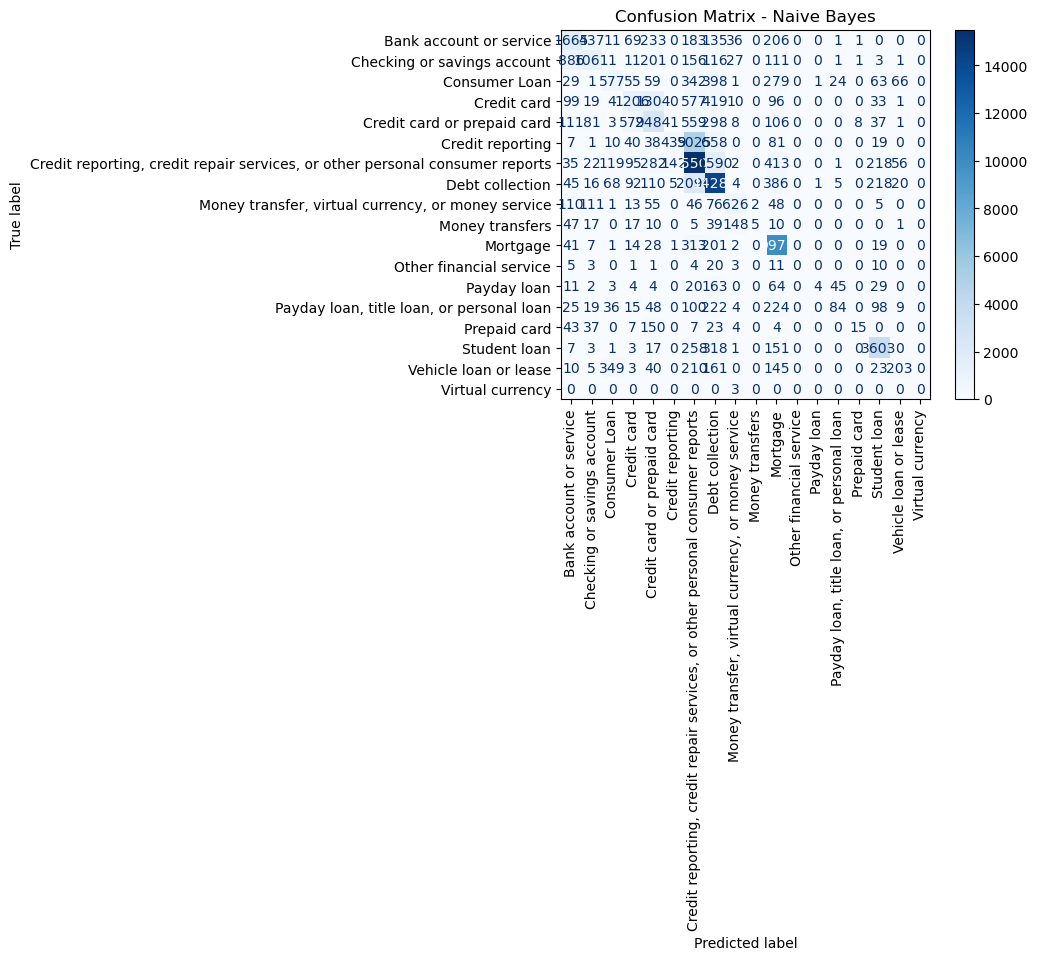


Top words for Bank account or service: ['funds' 'card' 'fees' 'overdraft' 'checking' 'money' 'check' 'account'
 'bank' 'xxxx']

Top words for Checking or savings account: ['chase' 'deposit' 'funds' 'checking' 'money' 'xxxxxxxx' 'check' 'bank'
 'account' 'xxxx']

Top words for Consumer Loan: ['paid' 'account' 'would' 'payments' 'credit' 'vehicle' 'payment' 'car'
 'loan' 'xxxx']

Top words for Credit card: ['late' 'would' 'interest' 'balance' 'payment' 'bank' 'account' 'credit'
 'card' 'xxxx']

Top words for Credit card or prepaid card: ['one' 'late' 'balance' 'bank' 'payment' 'xxxxxxxx' 'account' 'credit'
 'card' 'xxxx']

Top words for Credit reporting: ['transunion' 'accounts' 'reporting' 'experian' 'information' 'account'
 'equifax' 'report' 'credit' 'xxxx']

Top words for Credit reporting, credit repair services, or other personal consumer reports: ['removed' 'accounts' 'equifax' 'reporting' 'information' 'account'
 'xxxxxxxx' 'report' 'credit' 'xxxx']

Top words for Debt collection

Enter a consumer complaint description:  Company has responded to the consumer and the CFPB and chooses not to provide a public response



Predicted Product Category: Credit reporting, credit repair services, or other personal consumer reports

--- Sample Predictions ---
Complaint: The bank closed my account without any reason.
Predicted Product: Credit reporting, credit repair services, or other personal consumer reports

Complaint: Debt collectors are calling me repeatedly about a loan I don't owe.
Predicted Product: Debt collection

Complaint: My mortgage payment was not processed on time.
Predicted Product: Mortgage

Complaint: My credit card was charged twice by mistake.
Predicted Product: Credit card or prepaid card



In [2]:
# =======================
# 1. Import Dependencies
# =======================
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB

# Download stopwords
nltk.download('stopwords')

# =======================
# 2. Load Dataset
# =======================
path = "/kaggle/input/consumer-complaint-database/rows.csv"  # Change path if local
df = pd.read_csv(path, low_memory=False)

print("Dataset columns:", df.columns.tolist())

# Select only required columns
df = df[['Product', 'Consumer complaint narrative']].dropna()

print("\nSample Data:")
print(df.head())

# =======================
# 3. Preprocessing
# =======================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['cleaned_text'] = df['Consumer complaint narrative'].apply(clean_text)

# =======================
# 4. Encode Labels
# =======================
le = LabelEncoder()
df['label'] = le.fit_transform(df['Product'])
print("\nUnique Categories:", le.classes_)

# =======================
# 5. Split Data
# =======================
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# =======================
# 6. Vectorize Text
# =======================
vectorizer = TfidfVectorizer(max_features=3000)  # reduced features for speed
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# =======================
# 7. Train Model (Naive Bayes)
# =======================
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# =======================
# 8. Evaluate Model
# =======================
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

# 9. Top Features Per Class (fixed)
# =======================
feature_names = np.array(vectorizer.get_feature_names_out())
class_labels = le.classes_

# Get top words for each category
for i, class_label in enumerate(class_labels):
    top10 = np.argsort(model.feature_log_prob_[i])[-10:]
    print(f"\nTop words for {class_label}: {feature_names[top10]}")

# =======================
# 10. User Input Prediction
# =======================
print("\n--- User Input Mode ---")
user_input = input("Enter a consumer complaint description: ")
user_cleaned = clean_text(user_input)
user_vec = vectorizer.transform([user_cleaned])
prediction = model.predict(user_vec)
predicted_category = le.inverse_transform(prediction)[0]
print(f"\nPredicted Product Category: {predicted_category}")

# =======================
# 11. Sample Predictions
# =======================
sample_texts = [
    "The bank closed my account without any reason.",
    "Debt collectors are calling me repeatedly about a loan I don't owe.",
    "My mortgage payment was not processed on time.",
    "My credit card was charged twice by mistake."
]

print("\n--- Sample Predictions ---")
for text in sample_texts:
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = le.inverse_transform(model.predict(vec))[0]
    print(f"Complaint: {text}\nPredicted Product: {pred}\n")


In [3]:
# =======================
# 10. User Input Prediction
# =======================
print("\n--- User Input Mode ---")
user_input = input("Enter a consumer complaint description: ")
user_cleaned = clean_text(user_input)
user_vec = vectorizer.transform([user_cleaned])
prediction = model.predict(user_vec)
predicted_category = le.inverse_transform(prediction)[0]
print(f"\nPredicted Product Category: {predicted_category}")



--- User Input Mode ---


Enter a consumer complaint description:  The bank closed my account without any reason



Predicted Product Category: Credit reporting, credit repair services, or other personal consumer reports


In [5]:
# =======================
# 10. User Input Prediction
# =======================
print("\n--- User Input Mode ---")
user_input = input("Enter a consumer complaint description: ")

user_cleaned = clean_text(user_input)
user_vec = vectorizer.transform([user_cleaned])
prediction = model.predict(user_vec)
predicted_category = le.inverse_transform(prediction)[0]

print(f"\nPredicted Product Category: {predicted_category}")



--- User Input Mode ---


Enter a consumer complaint description:  My mortgage payment was not processed on time



Predicted Product Category: Mortgage
